In [2]:
import os

import numpy as np
import pandas as pd
from hapiclient import hapi
import time

# ---------------------------------------------------------------------------
# STEP 1 — DISCOVER the server, dataset, and parameter IDs.
# Run this first. Do NOT trust hardcoded IDs; CELIAS proton-monitor IDs vary
# by server. Read the printout, then fill in SERVER / DATASET / PARAMS below.
# ---------------------------------------------------------------------------
def discover(server):
    print(f"\n=== datasets on {server} ===")
    cat = hapi(server)                          # list datasets
    ids = [d['id'] for d in cat['catalog']]
    # CELIAS proton monitor usually has 'CELIAS' and 'PM' in the id
    hits = [i for i in ids if 'CELIAS' in i.upper() or 'PM' in i.upper()]
    for i in (hits or ids):
        print("  ", i)
    return ids

def show_params(server, dataset):
    print(f"\n=== parameters in {dataset} ===")
    meta = hapi(server, dataset)
    for p in meta['parameters']:
        print(f"  {p['name']:<20} {p.get('units','')}   {p.get('description','')}")

# Candidate servers to try (run discover on each):
#   "https://cdaweb.gsfc.nasa.gov/hapi"     <- most likely has SOHO_CELIAS-PM_30S
#   "https://hapi-server.org/servers"       <- aggregator/landing, not a HAPI endpoint
#
# Typical result you're hunting for:
#   dataset id : "SOHO_CELIAS-PM_5MIN"  (5-minute proton monitor)
#   params     : "V_p" (proton speed, km/s),  "N_p" (proton density, cm^-3)
# but CONFIRM the exact names from show_params() output.

# Example (uncomment to run):
# ids = discover("https://cdaweb.gsfc.nasa.gov/hapi")
# show_params("https://cdaweb.gsfc.nasa.gov/hapi", "SOHO_CELIAS-PM_30S")


# ---------------------------------------------------------------------------
# STEP 2 — Fill these in from the discovery output above.
# ---------------------------------------------------------------------------
SERVER  = "https://cdaweb.gsfc.nasa.gov/hapi"
DATASET = "SOHO_CELIAS-PM_5MIN"      # <-- CONFIRM
SPEED   = "V_p"                     # <-- CONFIRM (proton bulk speed, km/s)
DENSITY = "N_p"                      # <-- CONFIRM (proton density, cm^-3)

START_YEAR = 1996                   # CELIAS PM begins ~1996
END_YEAR   = 2024                   # full span of cycles 23, 24, rise of 25
MONTHS_PER_YEAR      = 4
FILL       = -1e31

CACHE = "celias_cache"
os.makedirs(CACHE, exist_ok=True)


# ---------------------------------------------------------------------------
# STEP 3 — Download year-by-year, then daily-average to de-correlate.
# Year chunks keep each request small, let you resume on failure, and are
# polite to the server. Daily averaging turns an autocorrelated 30s stream
# into ~one quasi-independent sample per day.
# ---------------------------------------------------------------------------
def download_window(server, dataset, params, start, stop):
    data, meta = hapi(server, dataset, params, start, stop)
    return pd.DataFrame({
        'time': pd.to_datetime([t.decode() if isinstance(t, bytes) else t
                                for t in data['Time']]),
        'w':   np.asarray(data[SPEED],   dtype=float),
        'rho': np.asarray(data[DENSITY], dtype=float),
    })

def build_dataset(server, dataset, speed, density,
                  y0=START_YEAR, y1=END_YEAR, months=MONTHS_PER_YEAR, pause=0.3):
    params = f"{speed},{density}"
    n_windows = 12 // months
    for i, year in enumerate(range(y0, y1 + 1)):
        start_month = 1 + (i % n_windows) * months
        start = f"{year}-{start_month:02d}-01T00:00:00Z"
        em = start_month + months
        stop = (f"{year+1}-{em-12:02d}-01T00:00:00Z" if em > 12
                else f"{year}-{em:02d}-01T00:00:00Z")

        fn = f"{CACHE}/{start[:7]}.csv"
        if os.path.exists(fn):                      # already have it -> skip
            print(f"  {start[:7]} cached"); continue
        for attempt in range(3):
            try:
                print(f"  {start[:7]} ...", end=" ", flush=True)
                df = download_window(server, dataset, params, start, stop)
                df.to_csv(fn, index=False)          # persist immediately
                print(f"{len(df)} rows"); break
            except Exception as e:
                print(f"retry {attempt+1} ({e})"); time.sleep(5)
        time.sleep(pause)

    frames = [pd.read_csv(f"{CACHE}/{f}") for f in sorted(os.listdir(CACHE))]
    raw = pd.concat(frames, ignore_index=True)
    raw['time'] = pd.to_datetime(raw['time'])
    raw[['w','rho']] = raw[['w','rho']].where(raw[['w','rho']] > FILL/2)
    raw = raw[(raw['w'].between(150,1200)) & (raw['rho'].between(0,200))].dropna()
    daily = (raw.set_index('time').resample('1D')[['w','rho']]
                .mean().dropna().reset_index())
    return raw, daily


In [2]:
# ---------------------------------------------------------------------------
# STEP 4 — run it
# ---------------------------------------------------------------------------
raw, daily = build_dataset(SERVER, DATASET, SPEED, DENSITY)
daily.to_csv("celias_w_rho_daily.csv", index=False) 
print(f"\n{len(daily)} daily samples spanning {daily.time.min()} .. {daily.time.max()}")

  1996-01 ... 27215 rows
  1997-05 ... 35031 rows
  1998-09 ... 13252 rows
  1999-01 ... 23282 rows
  2000-05 ... 35075 rows
  2001-09 ... 34771 rows
  2002-01 ... 30812 rows
  2003-05 ... 32507 rows
  2004-09 ... 30186 rows
  2005-01 ... 33370 rows
  2006-05 ... 33904 rows
  2007-09 ... 33932 rows
  2008-01 ... 33626 rows
  2009-05 ... 31734 rows
  2010-09 ... 34280 rows
  2011-01 ... 32354 rows
  2012-05 ... 33209 rows
  2013-09 ... 33871 rows
  2014-01 ... 33947 rows
  2015-05 ... 33189 rows
  2016-09 ... 31289 rows
  2017-01 ... 32760 rows
  2018-05 ... 31283 rows
  2019-09 ... 28926 rows
  2020-01 ... 29253 rows
  2021-05 ... 23114 rows
  2022-09 ... 31552 rows
  2023-01 ... 32570 rows
  2024-05 ... 

C:\Users\Lukas\AppData\Local\Temp\ipykernel_13524\391123660.py:69: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'time': pd.to_datetime([t.decode() if isinstance(t, bytes) else t


retry 1 (Unknown datetime string format, unable to parse: {
"HAPI": "2.0",
"status)
  2024-05 ... 

C:\Users\Lukas\AppData\Local\Temp\ipykernel_13524\391123660.py:69: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'time': pd.to_datetime([t.decode() if isinstance(t, bytes) else t


retry 2 (Unknown datetime string format, unable to parse: {
"HAPI": "2.0",
"status)
  2024-05 ... 

C:\Users\Lukas\AppData\Local\Temp\ipykernel_13524\391123660.py:69: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'time': pd.to_datetime([t.decode() if isinstance(t, bytes) else t


retry 3 (Unknown datetime string format, unable to parse: {
"HAPI": "2.0",
"status)

3227 daily samples spanning 1996-01-20 00:00:00+00:00 .. 2023-04-30 00:00:00+00:00


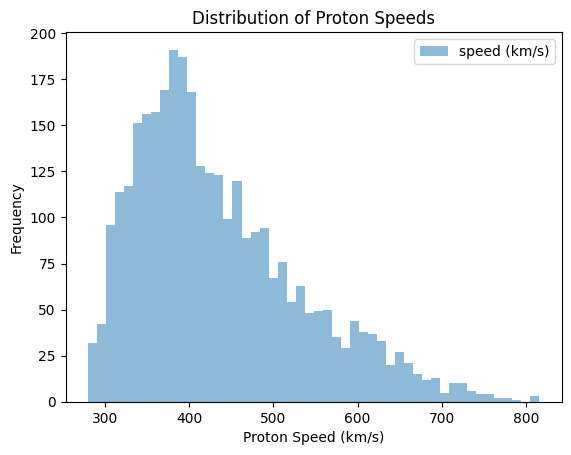

In [6]:
import matplotlib.pyplot as plt

plt.hist(daily.w, bins=50, alpha=0.5, label='speed (km/s)')
plt.xlabel('Proton Speed (km/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Proton Speeds')
plt.legend()
plt.show()

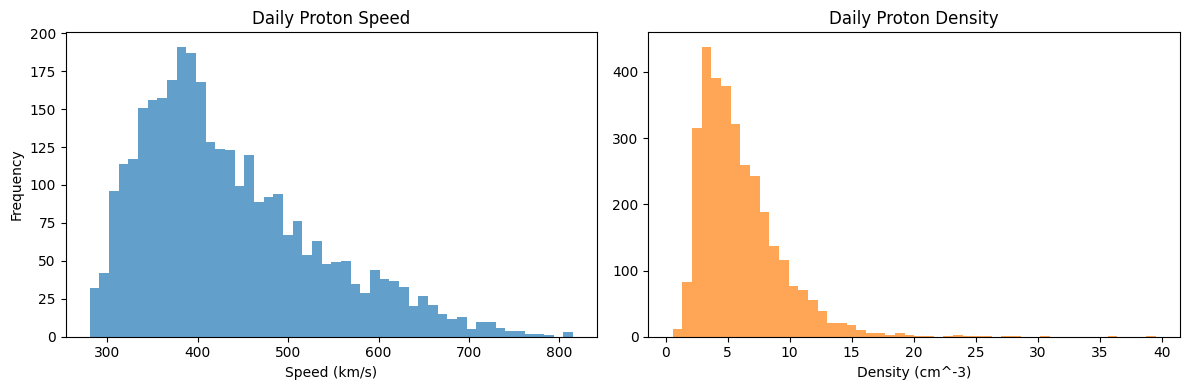

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axs[0].hist(daily.w, bins=50, alpha=0.7, color='tab:blue')
axs[0].set_title('Daily Proton Speed')
axs[0].set_xlabel('Speed (km/s)')
axs[0].set_ylabel('Frequency')

axs[1].hist(daily.rho, bins=50, alpha=0.7, color='tab:orange')
axs[1].set_title('Daily Proton Density')
axs[1].set_xlabel('Density (cm^-3)')

plt.tight_layout()
plt.show()

In [4]:
r_0 = 1.3914*10**7
AU_KM = 1.495978707e8

In [6]:
napoletano_set = pd.read_csv('ICME_complete_dataset_v3.csv')

napoletano_set = napoletano_set.iloc[1:].copy()

cols_to_convert = ['Mass', 'v_r', 'rel_wid', 'Transit_time', 'Arrival_v', 'Analyitic_w']
napoletano_set[cols_to_convert] = napoletano_set[cols_to_convert].apply(pd.to_numeric, errors='coerce')

lampani_set = napoletano_set.loc[
    (napoletano_set['Mass'] != -9999.0), 
    ['Start_Date', 'Transit_time', 'v_r', 'Mass', 'rel_wid']
].copy()


lampani_set['A'] = np.pi * (r_0 * np.sin(lampani_set['rel_wid'] / 2)) ** 2

lampani_set

,Start_Date,Transit_time,v_r,Mass,rel_wid,A
1,1997-01-07 08:35:05.600,67.415000,190.53,5.800000e+14,0.558505,4.620937e+13
2,1997-02-07 07:35:12.440,66.413056,705.35,4.100000e+15,0.785398,8.907036e+13
3,1997-04-07 17:26:59.000,84.550278,1133.70,1.000000e+16,1.151917,1.804145e+14
4,1997-05-12 09:00:08.640,71.997500,774.63,4.200000e+15,0.785398,8.907036e+13
5,1997-05-22 07:41:17.480,104.311667,354.13,2.200000e+15,0.558505,4.620937e+13
...,...,...,...,...,...,...
205,2016-01-15 11:30:23.000,94.493611,264.55,3.000000e+15,0.558505,4.620937e+13
206,2016-04-10 16:02:12.440,88.963056,685.60,4.600000e+15,0.785398,8.907036e+13
207,2016-07-17 17:45:17.960,61.245000,510.31,6.100000e+14,0.785398,8.907036e+13
208,2016-07-29 08:20:33.680,101.657222,523.18,3.900000e+14,0.785398,8.907036e+13


In [ ]:
import os, time

WINDOW_HOURS = 1
WINDOW_COL   = 'Start_Date'
CACHE = "celias_per_event"
os.makedirs(CACHE, exist_ok=True)

def fetch_event_w_rho(start_dt, event_id):
    """Return (mean_w, mean_rho, n_points) for a 1h window, cached per event."""
    fn = f"{CACHE}/{event_id}.csv"
    if os.path.exists(fn):
        c = pd.read_csv(fn)
        return c['w'].iloc[0], c['rho'].iloc[0], int(c['n'].iloc[0])

    start = pd.Timestamp(start_dt).tz_localize(None)
    stop  = start + pd.Timedelta(hours=WINDOW_HOURS)
    s = start.strftime("%Y-%m-%dT%H:%M:%SZ")
    e = stop.strftime("%Y-%m-%dT%H:%M:%SZ")

    for attempt in range(3):
        try:
            data, _ = hapi(SERVER, DATASET, f"{SPEED},{DENSITY}", s, e)
            w   = np.asarray(data[SPEED],   dtype=float)
            rho = np.asarray(data[DENSITY], dtype=float)
            m = (w > FILL/2) & (rho > FILL/2) & (w > 150) & (w < 1200) & (rho > 0) & (rho < 200)
            if m.sum() == 0:
                mw, mr, n = np.nan, np.nan, 0
            else:
                mw, mr, n = float(np.mean(w[m])), float(np.mean(rho[m])), int(m.sum())
            pd.DataFrame({'w':[mw], 'rho':[mr], 'n':[n]}).to_csv(fn, index=False)
            return mw, mr, n
        except Exception as ex:
            if attempt == 2:
                pd.DataFrame({'w':[np.nan],'rho':[np.nan],'n':[0]}).to_csv(fn, index=False)
                return np.nan, np.nan, 0
            time.sleep(4)

def attach_w_rho(df, date_col=WINDOW_COL, pause=0.3):
    ws, rs, ns = [], [], []
    for i, (_, row) in enumerate(df.iterrows()):
        eid = pd.Timestamp(row[date_col]).strftime("%Y%m%dT%H%M%S")
        w, r, n = fetch_event_w_rho(row[date_col], eid)
        ws.append(w); rs.append(r); ns.append(n)
        if i % 10 == 0: print(f"  {i}/{len(df)}  {eid}  w={w}  rho={r}  n={n}")
        if not os.path.exists(f"{CACHE}/{eid}.csv"): time.sleep(pause)
    out = df.copy()
    out['w'], out['rho'], out['n_pts'] = ws, rs, ns
    return out


In [8]:
lampani_set = attach_w_rho(lampani_set)
print("events with no CELIAS coverage:", lampani_set['n_pts'].eq(0).sum())
lampani_set

  0/164  19970107T083505  w=393.75  rho=9.40499997138977  n=12
  10/164  19971023T164538  w=376.6666666666667  rho=16.274999777475994  n=12
  20/164  19980502T161735  w=605.3636363636364  rho=3.5763636502352627  n=11
  30/164  20000210T050724  w=450.0  rho=4.692727283997969  n=11
  40/164  20000606T174243  w=440.25  rho=2.5550000071525574  n=12
  50/164  20001002T230014  w=389.27272727272725  rho=9.290909160267223  n=11
  60/164  20010406T211729  w=470.5833333333333  rho=5.56250003973643  n=12
  70/164  20011022T220316  w=526.3333333333334  rho=8.211666782697042  n=12
  80/164  20030528T023125  w=683.2727272727273  rho=7.306363712657582  n=11
  90/164  20050831T142055  w=397.5  rho=23.9366668065389  n=12
  100/164  20101026T182256  w=574.4166666666666  rho=2.4274999499320984  n=12
  110/164  20110914T030849  w=523.5  rho=2.5591666301091514  n=12
  120/164  20120307T011610  w=382.90909090909093  rho=9.812727321277965  n=11
  130/164  20121109T192933  w=356.5  rho=4.29833338658015  n=12


,Start_Date,Transit_time,v_r,Mass,rel_wid,A,w,rho,n_pts
1,1997-01-07 08:35:05.600,67.415000,190.53,5.800000e+14,0.558505,4.620937e+13,393.750000,9.405000,12
2,1997-02-07 07:35:12.440,66.413056,705.35,4.100000e+15,0.785398,8.907036e+13,388.416667,8.311667,12
3,1997-04-07 17:26:59.000,84.550278,1133.70,1.000000e+16,1.151917,1.804145e+14,406.750000,5.085833,12
4,1997-05-12 09:00:08.640,71.997500,774.63,4.200000e+15,0.785398,8.907036e+13,294.916667,12.235833,12
5,1997-05-22 07:41:17.480,104.311667,354.13,2.200000e+15,0.558505,4.620937e+13,332.833333,11.165000,12
...,...,...,...,...,...,...,...,...,...
205,2016-01-15 11:30:23.000,94.493611,264.55,3.000000e+15,0.558505,4.620937e+13,403.454545,4.064545,11
206,2016-04-10 16:02:12.440,88.963056,685.60,4.600000e+15,0.785398,8.907036e+13,363.000000,7.045455,11
207,2016-07-17 17:45:17.960,61.245000,510.31,6.100000e+14,0.785398,8.907036e+13,463.250000,3.768333,12
208,2016-07-29 08:20:33.680,101.657222,523.18,3.900000e+14,0.785398,8.907036e+13,604.583333,4.564167,12


In [9]:
lampani_set.to_csv("lampani_set_with_celias.csv", index=False)